# 11 — Final plots for the report (Phase 12)

Polish pass. No new analysis — just **consistent typography, colors, and sizes** across the headline figures so the report and slide deck look professional.

**What we do here:**
1. Define a tiny matplotlib style (fonts, sizes, palette) used by every figure.
2. Re-render the four headline figures with that style:
   - Per-class recall comparison (baseline vs augmented) — **the headline figure**
   - Training curves (baseline + augmented overlaid)
   - FID per class (CVAE vs cGAN)
   - Compact summary table (macro-F1, balanced acc, per-class recall) as a figure
3. Export everything both as `report_*.png` (for screens/slides) and `report_*.pdf` (for the LaTeX report — vector, scales perfectly).

**Inputs** (all produced by earlier phases):
- `results/logs/baseline_resnet50_log.csv`
- `results/logs/augmented_resnet50_log.csv`
- `results/logs/comparison_baseline_vs_augmented.csv`
- `results/logs/fid_scores.csv`

**Outputs** (everything in `results/plots/report/`):
- `report_headline_recall.{png,pdf}`
- `report_training_curves.{png,pdf}`
- `report_fid.{png,pdf}`
- `report_summary_table.{png,pdf}`

## 1. Style definition

All figures pull from one place. If you want everything tweaked (bigger fonts, different palette), change it here once.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src.dataset import CLASS_NAMES   # noqa: E402

RESULTS    = PROJECT_ROOT / 'results'
REPORT_DIR = RESULTS / 'plots' / 'report'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# --- one style, used everywhere ---
COLORS = {
    'baseline':  '#888888',
    'augmented': '#2C5AA8',
    'cvae':      '#4C72B0',
    'cgan':      '#DD8452',
    'improve':   '#1A7F1A',
    'regress':   '#A00000',
    'neutral':   '#444444',
}
rcParams.update({
    'font.family':        'DejaVu Sans',     # available everywhere
    'font.size':          10,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.titlesize':   13,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'savefig.bbox':       'tight',
    'savefig.dpi':        300,
    'pdf.fonttype':       42,                 # editable text in PDF (TrueType, not bitmap)
    'ps.fonttype':        42,
})

def save_both(fig, name):
    """Save fig as PNG (slides) and PDF (LaTeX report)."""
    for ext in ('png', 'pdf'):
        out = REPORT_DIR / f'{name}.{ext}'
        fig.savefig(out)
        print(f'  saved {out.relative_to(PROJECT_ROOT)}')

print('Style loaded. Output dir:', REPORT_DIR.relative_to(PROJECT_ROOT))

Style loaded. Output dir: results/plots/report


## 2. The headline figure — per-class recall

Same data as Phase 10's `comparison_per_class_recall.png`, but with the report typography and a small inset showing the overall macro-F1 / balanced-accuracy delta. **This is the figure that goes on slide 1 of the defense and in the abstract of the report.**

  saved results/plots/report/report_headline_recall.png
  saved results/plots/report/report_headline_recall.pdf


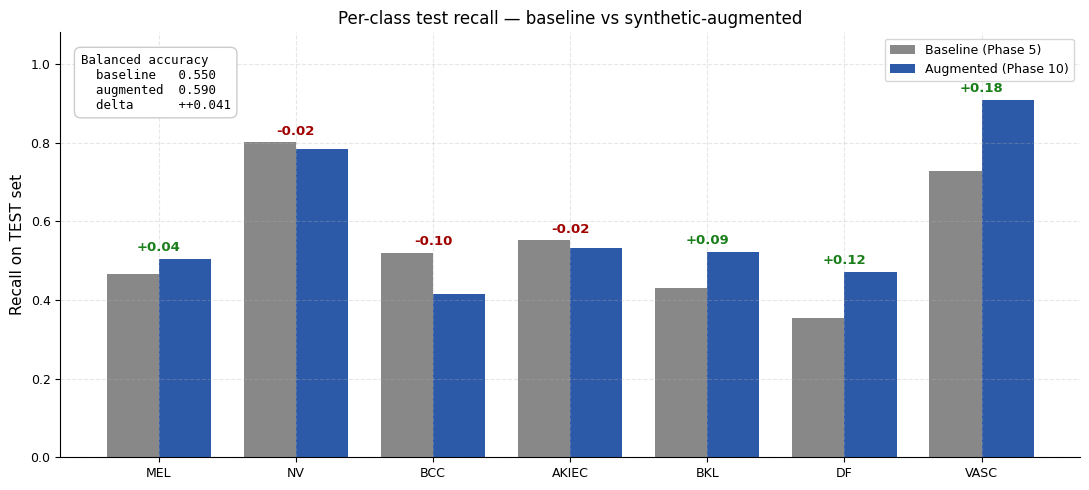

In [2]:
cmp = pd.read_csv(RESULTS / 'logs' / 'comparison_baseline_vs_augmented.csv')
# Drop the OVERALL summary row -- we'll show that in the inset
per_class = cmp[cmp['class'] != 'OVERALL'].reset_index(drop=True)
overall   = cmp[cmp['class'] == 'OVERALL'].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(per_class))
w = 0.38
ax.bar(x - w/2, per_class['baseline_recall'],   width=w, label='Baseline (Phase 5)',  color=COLORS['baseline'])
ax.bar(x + w/2, per_class['augmented_recall'],  width=w, label='Augmented (Phase 10)', color=COLORS['augmented'])
ax.set_xticks(x); ax.set_xticklabels(per_class['class'])
ax.set_ylabel('Recall on TEST set')
ax.set_ylim(0, 1.08)
ax.set_title('Per-class test recall — baseline vs synthetic-augmented')
ax.legend(loc='upper right')

# Annotate deltas
for i, row in per_class.iterrows():
    d = row['delta']
    y = max(row['baseline_recall'], row['augmented_recall']) + 0.02
    color = COLORS['improve'] if d > 0.01 else (COLORS['regress'] if d < -0.01 else COLORS['neutral'])
    sign  = '+' if d >= 0 else ''
    ax.text(i, y, f'{sign}{d:.2f}', ha='center', fontsize=9.5, color=color, fontweight='bold')

# Inset: overall balanced accuracy delta
delta_overall = overall['augmented_recall'] - overall['baseline_recall']
sign_o = '+' if delta_overall >= 0 else ''
txt = (f'Balanced accuracy\n'
       f'  baseline   {overall["baseline_recall"]:.3f}\n'
       f'  augmented  {overall["augmented_recall"]:.3f}\n'
       f'  delta      {sign_o}{delta_overall:+.3f}')
ax.text(0.02, 0.95, txt, transform=ax.transAxes, fontsize=9,
        va='top', ha='left', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc'))

plt.tight_layout()
save_both(fig, 'report_headline_recall')
plt.show()

## 3. Training curves — baseline + augmented overlaid

Shows that both models trained healthily and that the augmented model reaches a higher val macro-F1 plateau. Two panels: loss, macro-F1.

  saved results/plots/report/report_training_curves.png
  saved results/plots/report/report_training_curves.pdf


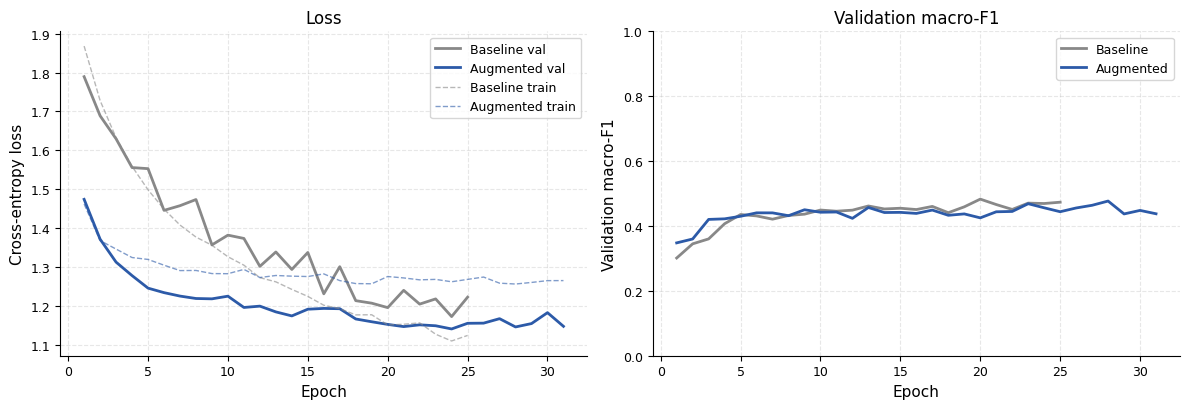

In [3]:
blog = pd.read_csv(RESULTS / 'logs' / 'baseline_resnet50_log.csv')
alog = pd.read_csv(RESULTS / 'logs' / 'augmented_resnet50_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Loss
axes[0].plot(blog['epoch'], blog['val_loss'], label='Baseline val',  color=COLORS['baseline'], linewidth=2)
axes[0].plot(alog['epoch'], alog['val_loss'], label='Augmented val', color=COLORS['augmented'], linewidth=2)
if 'train_loss' in blog.columns:
    axes[0].plot(blog['epoch'], blog['train_loss'], label='Baseline train',
                 color=COLORS['baseline'], linewidth=1, linestyle='--', alpha=0.6)
if 'train_loss' in alog.columns:
    axes[0].plot(alog['epoch'], alog['train_loss'], label='Augmented train',
                 color=COLORS['augmented'], linewidth=1, linestyle='--', alpha=0.6)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss'); axes[0].legend()

# Macro-F1 (val)
if 'val_macro_f1' in blog.columns:
    axes[1].plot(blog['epoch'], blog['val_macro_f1'], label='Baseline',
                 color=COLORS['baseline'], linewidth=2)
axes[1].plot(alog['epoch'], alog['val_macro_f1'], label='Augmented',
             color=COLORS['augmented'], linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation macro-F1')
axes[1].set_title('Validation macro-F1'); axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
save_both(fig, 'report_training_curves')
plt.show()

## 4. FID per class — CVAE vs cGAN

Same data as Phase 9's `fid_per_class.png`, restyled.

  saved results/plots/report/report_fid.png
  saved results/plots/report/report_fid.pdf


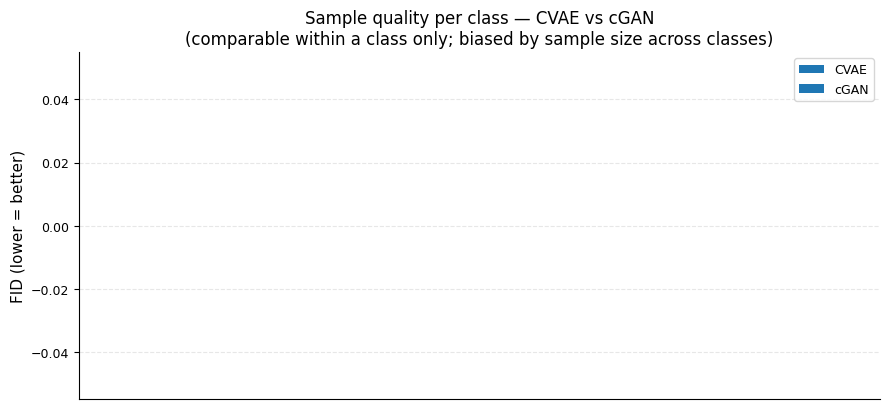

In [4]:
fid = pd.read_csv(RESULTS / 'logs' / 'fid_scores.csv')
scored = fid.dropna(subset=['fid_cvae', 'fid_cgan'], how='all').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(scored)); w = 0.38
ax.bar(x - w/2, scored['fid_cvae'], width=w, label='CVAE', color=COLORS['cvae'])
ax.bar(x + w/2, scored['fid_cgan'], width=w, label='cGAN', color=COLORS['cgan'])
ax.set_xticks(x); ax.set_xticklabels(scored['class_name'])
ax.set_ylabel('FID (lower = better)')
ax.set_title('Sample quality per class — CVAE vs cGAN\n(comparable within a class only; biased by sample size across classes)')
ax.legend()

for i, r in scored.iterrows():
    if pd.notna(r['fid_cvae']) and pd.notna(r['fid_cgan']):
        winner = 'CVAE' if r['fid_cvae'] < r['fid_cgan'] else 'cGAN'
        y = max(r['fid_cvae'], r['fid_cgan']) * 1.04
        ax.text(i, y, f'{winner} wins', ha='center', fontsize=9, color=COLORS['neutral'])

plt.tight_layout()
save_both(fig, 'report_fid')
plt.show()

## 5. Summary table (rendered as a figure)

Clean per-class table for the report's results section. Includes baseline recall, augmented recall, delta, and the synthetic-sample count per class. The delta column is colour-coded.

We render this as a matplotlib figure (not a LaTeX table) so it can be dropped in directly as an image, which is faster than writing tabular code in the report.

  saved results/plots/report/report_summary_table.png
  saved results/plots/report/report_summary_table.pdf


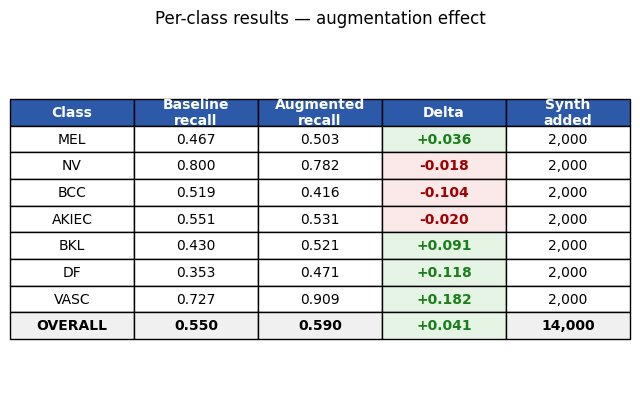

In [5]:
tbl = cmp.copy()
# Format columns for display
tbl['baseline_recall']  = tbl['baseline_recall'].map(lambda v: f'{v:.3f}')
tbl['augmented_recall'] = tbl['augmented_recall'].map(lambda v: f'{v:.3f}')
tbl['delta_fmt'] = tbl['delta'].map(lambda v: f'{v:+.3f}')
tbl['synth_added']      = tbl['synth_added'].map(lambda v: f'{int(v):,}')

display_cols = ['class', 'baseline_recall', 'augmented_recall', 'delta_fmt', 'synth_added']
header_labels = ['Class', 'Baseline\nrecall', 'Augmented\nrecall', 'Delta', 'Synth\nadded']

fig, ax = plt.subplots(figsize=(8, 0.45 * (len(tbl) + 1) + 0.6))
ax.axis('off')

cell_text  = tbl[display_cols].values.tolist()
table = ax.table(cellText=cell_text, colLabels=header_labels,
                 loc='center', cellLoc='center', colLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)

# Style the header
for j in range(len(header_labels)):
    c = table[0, j]
    c.set_facecolor('#2C5AA8')
    c.set_text_props(color='white', fontweight='bold')

# Colour the delta column by sign
delta_col_idx = display_cols.index('delta_fmt')
for i, d in enumerate(tbl['delta'].values):
    c = table[i + 1, delta_col_idx]
    if d > 0.01:
        c.set_facecolor('#e6f4e6')
        c.set_text_props(color=COLORS['improve'], fontweight='bold')
    elif d < -0.01:
        c.set_facecolor('#fbe9e9')
        c.set_text_props(color=COLORS['regress'], fontweight='bold')

# Bold the OVERALL row
for j in range(len(display_cols)):
    overall_idx = tbl.index[tbl['class'] == 'OVERALL']
    if len(overall_idx) > 0:
        c = table[overall_idx[0] + 1, j]
        c.set_facecolor(c.get_facecolor() if j == delta_col_idx else '#f0f0f0')
        existing_color = c.get_text().get_color()
        c.set_text_props(fontweight='bold', color=existing_color)

ax.set_title('Per-class results — augmentation effect', pad=12, fontsize=12)
save_both(fig, 'report_summary_table')
plt.show()

## 6. Quick file inventory for the report

What to include in the report and where each figure goes.

In [6]:
print('Report figures written to:', REPORT_DIR.relative_to(PROJECT_ROOT))
print()
for f in sorted(REPORT_DIR.iterdir()):
    if f.is_file():
        kb = f.stat().st_size / 1024
        print(f'  {f.name:<40}  {kb:6.1f} KB')

print('\nSuggested placement in the report:')
print('  Abstract / Intro    : report_headline_recall.pdf (the result in one chart)')
print('  Methods - generators: synthetic_grid_cvae.png, synthetic_grid_cgan.png  (Phase 8)')
print('  Methods - quality   : report_fid.pdf')
print('  Results - training  : report_training_curves.pdf')
print('  Results - main      : report_summary_table.pdf  +  report_headline_recall.pdf')
print('  Discussion          : gradcam_correct_rare_classes.png  (Phase 11)')
print('  Discussion          : confusion_baseline_vs_augmented.png  (Phase 11)')
print('  Limitations         : failure_cases.png  (Phase 11)')

Report figures written to: results/plots/report

  report_fid.pdf                              12.2 KB
  report_fid.png                              95.9 KB
  report_headline_recall.pdf                  26.2 KB
  report_headline_recall.png                 159.1 KB
  report_summary_table.pdf                    22.7 KB
  report_summary_table.png                   151.7 KB
  report_training_curves.pdf                  14.1 KB
  report_training_curves.png                 247.9 KB

Suggested placement in the report:
  Abstract / Intro    : report_headline_recall.pdf (the result in one chart)
  Methods - generators: synthetic_grid_cvae.png, synthetic_grid_cgan.png  (Phase 8)
  Methods - quality   : report_fid.pdf
  Results - training  : report_training_curves.pdf
  Results - main      : report_summary_table.pdf  +  report_headline_recall.pdf
  Discussion          : gradcam_correct_rare_classes.png  (Phase 11)
  Discussion          : confusion_baseline_vs_augmented.png  (Phase 11)
  Limitatio